In [1]:
import gensim.downloader as api
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import spacy
import random

# Load models
word2vec_model = api.load("word2vec-google-news-300")
nlp = spacy.load("en_core_web_sm")

C:\Users\batti\AppData\Roaming\Python\Python39\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_random_words(n=20):
    """Get random words from spaCy vocabulary."""
    return random.sample(list(nlp.vocab.strings), n)

# def get_random_words(n=20, word2vec_model=None):
#     """Get random words from the Word2Vec vocabulary."""
#     if word2vec_model is None:
#         raise ValueError("word2vec_model must be provided")
        
#     # Get the list of words in the Word2Vec model
#     vocab_words = word2vec_model.index_to_key  # or word2vec_model.key_to_index.keys()
    
#     return random.sample(vocab_words, n)

def perform_analogy(model, word1, word2, word3, topn=5):
    """Perform word analogy using Word2Vec model."""
    result = model.most_similar(positive=[word1, word3], negative=[word2], topn=topn)
    return result

def get_tsne_plot(word1, word2, word3, result, random_words):
    """Generate and display a t-SNE plot for the words."""
    # Combine the words to be plotted
    words = [word1, word2, word3, result[0][0]] + [r[0] for r in result[1:6]] + random_words
    
    # Get vectors for all the words, filtering out any that are not in the Word2Vec model
    vectors = []
    valid_words = []
    for word in words:
        if word in word2vec_model.key_to_index:
            valid_words.append(word)
            vectors.append(word2vec_model[word])

    # Check if we have enough valid vectors to plot
    if len(vectors) < 2:
        print("Not enough valid words for t-SNE plot.")
        return

    # Convert the list of vectors to a NumPy array
    vectors = np.array(vectors)

    # Apply t-SNE with a suitable perplexity
    tsne = TSNE(n_components=2, perplexity=min(10, len(vectors) - 1), random_state=42)
    embeddings = tsne.fit_transform(vectors)

    # Plotting the words
    plt.figure(figsize=(10, 8))
    for i, word in enumerate(valid_words):
        plt.scatter(embeddings[i, 0], embeddings[i, 1])
        plt.annotate(word, (embeddings[i, 0], embeddings[i, 1]), fontsize=9)

    # Draw a line connecting the four words of the analogy
    if len(valid_words) >= 4:
        plt.plot(embeddings[[0, 1, 2, 3], 0], embeddings[[0, 1, 2, 3], 1], color='red', linestyle='dashed')

    plt.title('t-SNE visualization of word embeddings')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid()
    plt.show()




Top five words for king - man + woman: ['queen', 'monarch', 'princess', 'crown_prince', 'prince']
Randomly generated 20 words: ['Quada', 'picc', 'wary', 'amiable', 'sssssr', 'lustful', 'ccp', 'Debenture', 'stadium', 'Commander', '31.2', 'operas', 'hewed', 'Xinbaotianyang', 'McAlu', '168.1', 'marietta', 'gene', 'Tristars', 'gee']


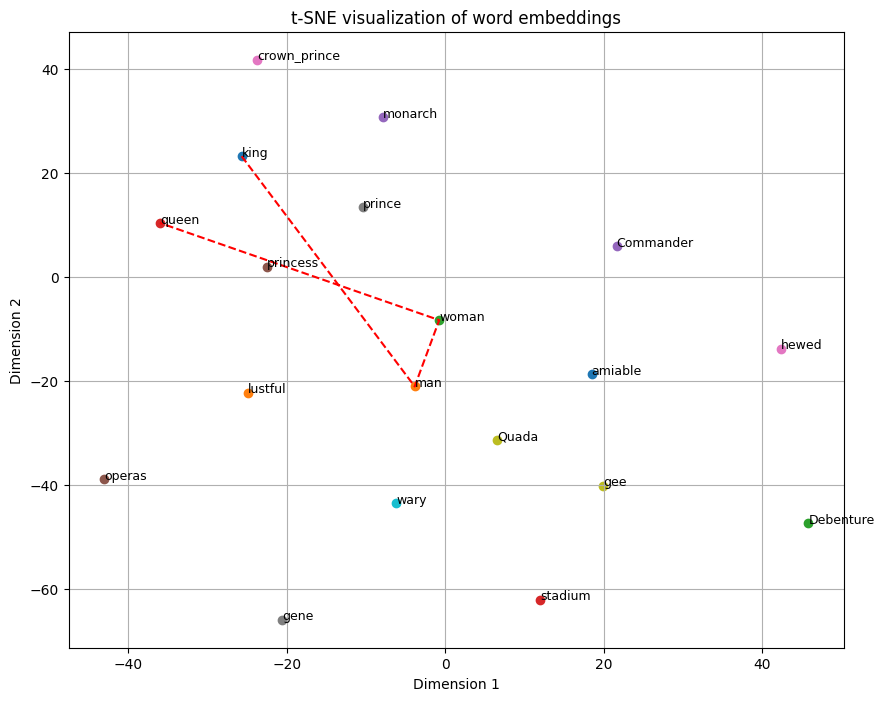

Top five words for doctor - man + woman: ['gynecologist', 'nurse', 'doctors', 'physician', 'pediatrician']
Randomly generated 20 words: ['824', '162.19', 'involvement', 'Siberia', 'phalangist', 'sleeved', 'Choo', 'curt', 'lep', 'uninteresting', 'cancelation', '.44', 'xx’xx', '782', 'co-op', 'therapists', 'watan', 'Mariano', 'Trelleborg', 'mercenaries']


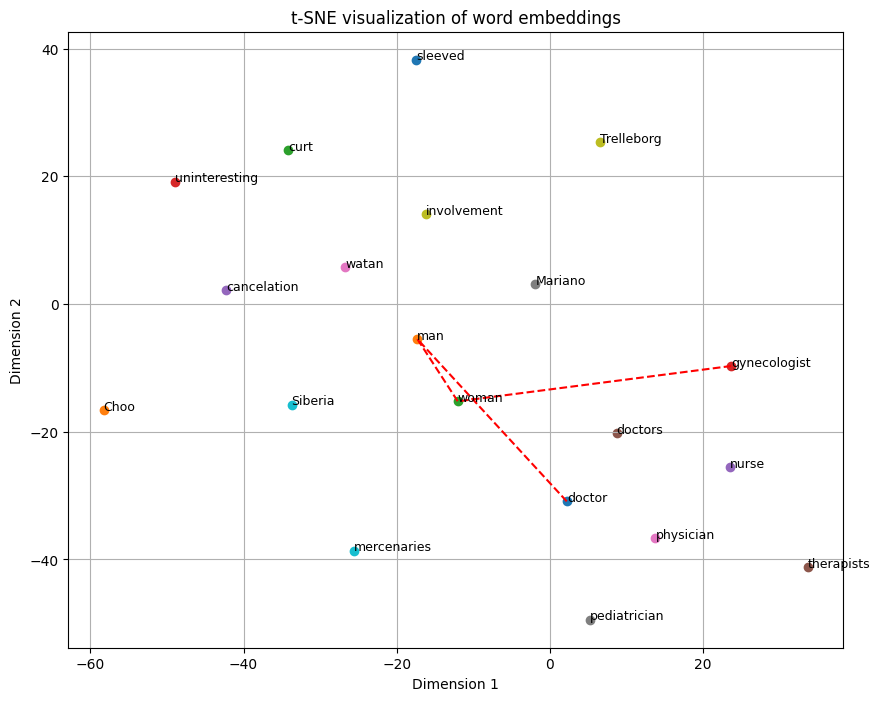

Top five words for France - Italy + rome: ['france', 'paris', 'je_suis', 'alors', 'vous']
Randomly generated 20 words: ['carcinoma', 'jowl', 'apiece', 'medals', 'MIPS', 'tri', 'Aloft', 'Giles', 'Mainland', 'Neinas', 'deserving', 'mid-1990s', 'priscilla', 'xxx_xxxxdd@xxxx.xxx', 'sewing', 'stallone', 'Povich', 'newswire', 'Sonet', 'mire']


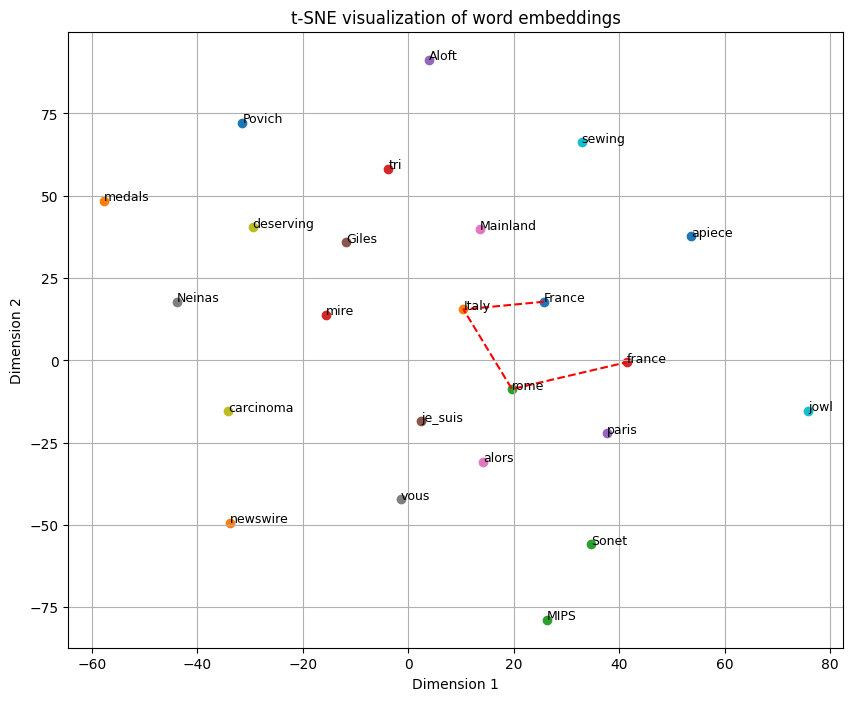

Top five words for Florida - Texas + Austin: ['Fort_Lauderdale', 'Tampa', 'West_Palm_Beach', 'Orlando', 'Tallahassee']
Randomly generated 20 words: ['ogg', '128.9', 'SENIOR', 'latched', 'tibbles', 'barbara', 'aux||xcomp', 'circumvent', 'Jumblatts', 'paves', 'xx’x', 'underutilized', '**junkmobile**', 'kfc', 'montreal', 'isabella', '647', 'reincorporating', 'Aiah', 'Linear']


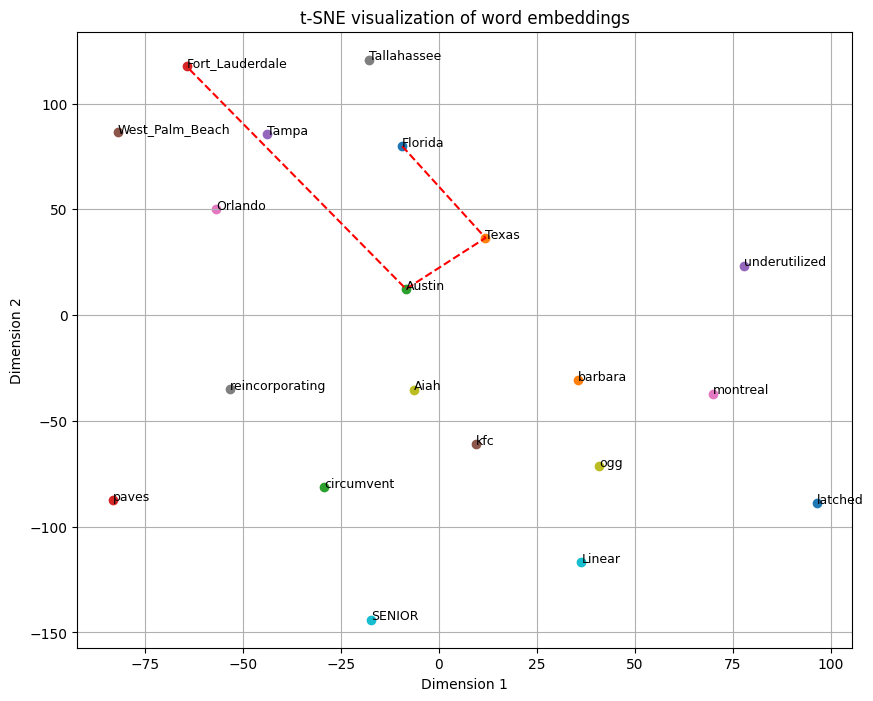

In [6]:
def main(word1, word2, word3):
    """
    Main function to perform word analogy, retrieve top 5 similar words, get random words, and generate t-SNE plot.
    """
    # Perform the word analogy
    result = perform_analogy(word2vec_model, word1, word2, word3)
    print(f'Top five words for {word1} - {word2} + {word3}: {[r[0] for r in result]}')
    
    # Get 20 random words from spaCy vocabulary
    random_words = get_random_words(20)
    # Get 20 random words from word2vec vocabulary
    # random_words = get_random_words(20, word2vec_model)
    print(f'Randomly generated 20 words: {random_words}')
    
    # Generate and display t-SNE plot
    get_tsne_plot(word1, word2, word3, result, random_words)

# Example usage for different analogies
if __name__ == "__main__":
    main('king', 'man', 'woman')  # Analogy: king - man + woman ≈ ?
    main('doctor', 'man', 'woman')  # Analogy: doctor - man + woman ≈ ?
    main('France', 'Italy', 'rome')  # Analogy: France - Italy + rome ≈ ?
    main('Florida', 'Texas', 'Austin')  # Analogy: Florida - Texas + Austin ≈ ?